# Tarea 3: Cadenas de Markov

## Problema 1: dos contenedores de partículas

El proceso es de Markov porque el futuro de un sistema depende únicamente de su estado presente, no de cómo llegó hasta él. Esto sucede ya que queda determinada solo por cuántas partículas hay actualmente en A y B: hay $k$ partículas en A y $N-k$ en B. No hace falta conocer la historia anterior. Esto cumple con la propiedad de Markov.

En cada paso se elige uniformemente una de las $N$ partículas. Si la partícula elegida está en A, se mueve a B y $X$ disminuye en 1 y si está en B, se mueve a A y $X$ aumenta en 1. Por tanto,
$$
P(X_{t+1}=X_t-1)=\frac{X_t}{N},\quad
P(X_{t+1}=X_t+1)=\frac{X_t}{N},
$$

- Caso $X_t=0$, la partícula que se escoge debe estar en $B$, por lo tanto, una probabilidad de $1$ de que se mueva a $A$.
- Caso $X_t=1$, la probabilidad de la partítula esté en $A$ es de $1/5$, entonces habría una probabilidad de $1/5$ de que se le reste esa partícula y de $4/5$ de que se agregue otra de $B$ y quede en $3$.
- Caso $X_t=2$, $2/5$ para $1$ y $3/5$ para $3$.
- Caso $X_t=3$, $3/5$ para $2$ y $2/5$ para $4$.
- Caso $X_t=4$, $4/5$ para $3$ y $1/5$ para $5$.
- Caso $X_t=5$, $1$ para $4$.

$$
Q=\begin{pmatrix}
0 & 1/5 & 0 & 0 & 0 & 0\\
1 & 0 & 2/5 & 0 & 0 & 0\\
0 & 4/5 & 0 & 3/5 & 0 & 0\\
0 & 0 & 3/5 & 0 & 4/5 & 0\\
0 & 0 & 0 & 2/5 & 0 & 1\\
0 & 0 & 0 & 0 & 1/5 & 0
\end{pmatrix}
$$

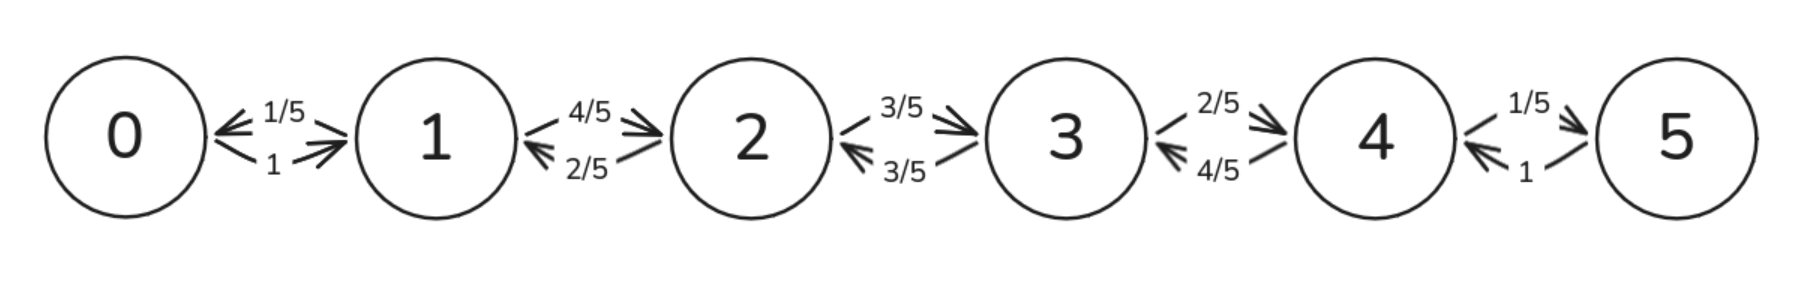

Para encontrar el estado estacionario usamos balance detallado,
$$
Q_{nm}P_m^*=Q_{mn}P_n^*
$$

Con $X_t=k$
$$
P_k^*Q_{k+1,k}=P_{k+1}^*Q_{k,k+1}
$$
Como $Q_{k+1,k}=(N-k)/N$ y $Q_{k,k+1}=(k+1)/N$,
$$
\frac{P_{k+1}^*}{P_k^*}=\frac{N-k}{k+1}
$$
Ahora calculamos los primeros términos a partir de la relación anterior. Para $k=0$,
$$
P_1^*=P_0^*\frac{N}{1}=NP_0^*
$$
Para $k=1$,
$$
P_2^*=P_1^*\frac{N-1}{2}=P_0^*\frac{N(N-1)}{2}
$$
Para $k=2$,
$$
P_3^*=P_2^*\frac{N-2}{3}=P_0^*\frac{N(N-1)(N-2)}{3!}
$$
Ahora partimos del coeficiente binomial y lo reescribimos como
$$
\binom Nk=\frac{N!}{k!(N-k)!}=\frac{N(N-1)\cdots(N-k+1)}{k!}
$$
Esta expresión coincide con el factor que aparece en los primeros términos calculados arriba. Por tanto,
$$
P_k^*=P_0^*\binom Nk
$$
La normalización da
$$
1=\sum_{k=0}^N P_k^*=P_0^*\sum_{k=0}^N\binom Nk=P_0^*2^N,
$$
por lo que
$$
\boxed{P_k^*=\binom Nk\left(\frac12\right)^N},\qquad k=0,\ldots,N
$$
Por lo tanto, $P_k^*$ es una distribución binomial con parámetros $(N,p=1/2)$

Entonces el estado estacionario de la cadena es la distribución
$$
\boxed{\vec P^*=\left(P_0^*,P_1^*,\ldots,P_N^*\right),\qquad P_k^*=\binom Nk\left(\frac12\right)^N}
$$
Para el caso particular $N=5$, el estado estacionario es
$$
\boxed{\vec P^*=\frac{1}{32}(1,5,10,10,5,1)^T}
$$

## Problema 2: rey en un tablero $M\times M$

Para $M\ge 2$, hay tres tipos de casillas:

- $4$ esquinas, cada una con $3$ movimientos legales.
- $4(M-2)$ bordes que no son esquina, cada uno con $5$ movimientos legales.
- $(M-2)^2$ casillas interiores, cada una con $8$ movimientos legales.

Por normalización, el total que divide a todas las probabilidades es
$$
\text{total}=4(3)+4(M-2)(5)+(M-2)^2(8)=8M^2-12M+4
$$
Entonces el estado estacionario es
$$
\boxed{
P_{i,j}^*=\begin{cases}
\dfrac{3}{8M^2-12M+4}, & \text{si }(i,j)\text{ es esquina}\\
\dfrac{5}{8M^2-12M+4}, & \text{si }(i,j)\text{ es borde}\\
\dfrac{8}{8M^2-12M+4}, & \text{si }(i,j)\text{ es interior}
\end{cases}}
$$

## Problema 3: la moneda de Markov

### a) Matriz de transición

Si Markov está tirando, con probabilidad $1/2$ sale escudo y sigue tirando; con probabilidad $1/2$ sale corona y termina. Si ya terminó, permanece terminado. Entonces
$$
\boxed{
Q=\begin{pmatrix}
1/2 & 0\\
1/2 & 1
\end{pmatrix}}
$$

### b) Irreducibilidad, aperiodicidad y distribución estacionaria

Una cadena es irreducible si todos los estados se comunican, es decir, si desde cualquier estado se puede llegar eventualmente a cualquier otro. En esta cadena eso no se cumple: una vez que el proceso llega al estado finalizado, permanece ahí y no existe transición de regreso al estado en que se sigue tirando la moneda.

El estado finalizado tiene retorno en un paso, porque al estar finalizado se queda finalizado con probabilidad $1$. Entonces su periodo es $1$, y por lo tanto es aperiódica.

La cadena sí tiene distribución estacionaria. Si toda la probabilidad está en el estado finalizado, aplicar $Q$ no cambia la distribución.

### c) Autovectores izquierdos y derechos

El estado estacionario satisface $Q\vec P^*=\vec P^*$, por lo que corresponde al autovector derecho con autovalor $1$.

Primero obtenemos los autovalores de
$$
Q=\begin{pmatrix}1/2&0\\1/2&1\end{pmatrix}
$$
Entonces
$$
\det(Q-\lambda I)=
\det\begin{pmatrix}1/2-\lambda&0\\1/2&1-\lambda\end{pmatrix}
=(1/2-\lambda)(1-\lambda)
$$
Por tanto,
$$
\boxed{\lambda_1=1,\qquad \lambda_2=\frac12}
$$

Para los autovectores derechos resolvemos $(Q-\lambda I)\vec v=0$, con $\vec v=(a,b)^T$.

Para $\lambda_1=1$,
$$
Q-I=\begin{pmatrix}-1/2&0\\1/2&0\end{pmatrix},
\quad -\frac12 a=0 \Rightarrow a=0
$$
El parámetro $b$ queda libre; escogiendo $b=1$,
$$
\boxed{\vec v_1=\begin{pmatrix}0\\1\end{pmatrix}}
$$
Este es el autovector que corresponde al estado estacionario $\vec P^*$.

Para $\lambda_2=1/2$,
$$
Q-\frac12 I=\begin{pmatrix}0&0\\1/2&1/2\end{pmatrix},
\quad \frac12 a+\frac12 b=0 \Rightarrow b=-a
$$
Escogiendo $a=1$,
$$
\boxed{\vec v_2=\begin{pmatrix}1\\-1\end{pmatrix}}
$$

Para los autovectores izquierdos,
para $\lambda_1=1$ se obtiene
$$
Q^T-I=\begin{pmatrix}-1/2&1/2\\0&0\end{pmatrix},
\quad -\frac12 c+\frac12 d=0 \Rightarrow c=d
$$
Escogiendo $c=d=1$,
$$
\boxed{\vec w_1=(1,1)}
$$
Para $\lambda_2=1/2$,
$$
Q^T-\frac12 I=\begin{pmatrix}0&1/2\\0&1/2\end{pmatrix},
\quad \frac12 d=0 \Rightarrow d=0
$$
Escogiendo $c=1$,
$$
\boxed{\vec w_2=(1,0)}
$$

### d) Normalización de $\tilde P$

El otro autovector derecho encontrado en el inciso anterior corresponde al autovalor $\lambda_2=1/2$:
$$
\vec v_2=\begin{pmatrix}1\\-1\end{pmatrix}
$$

$$
\|\vec v_2\|=\sqrt{1^2+(-1)^2}=\sqrt2
$$

$$
\boxed{\tilde P=\frac{\vec v_2}{\|\vec v_2\|}=\frac{1}{\sqrt2}\begin{pmatrix}1\\-1\end{pmatrix}}
$$

### e) Condiciones sobre $A$ y $B$

Si
$$
\vec P_0=A\vec P^*+B\tilde P,
$$
entonces
$$
\vec P_0=A\begin{pmatrix}0\\1\end{pmatrix}+\frac{B}{\sqrt2}\begin{pmatrix}1\\-1\end{pmatrix}
=\begin{pmatrix}B/\sqrt2\\A-B/\sqrt2\end{pmatrix}
$$
Para que sea una distribución de probabilidad válida debe cumplir no negatividad y normalización:
$$
\frac{B}{\sqrt2}\ge0,
\qquad A-\frac{B}{\sqrt2}\ge0,
\qquad \frac{B}{\sqrt2}+\left(A-\frac{B}{\sqrt2}\right)=A=1
$$
Entonces
$$
\boxed{A=1,\qquad 0\le B\le\sqrt2}
$$

### f) Evolución temporal

Como $Q\vec P^*=\vec P^*$ y $Q\tilde P=\frac12\tilde P$,
$$
\boxed{
\vec P_0(t)=Q^t\vec P_0=A\vec P^*+B\left(\frac12\right)^t\tilde P
}
$$

### g) Límite de tiempo largo

$$
\boxed{\lim_{t\to\infty}\vec P_0(t)=\begin{pmatrix}0\\1\end{pmatrix}}
$$
Eventualmente sale corona con probabilidad 1 y el proceso queda en ese estado.


## Problema 4: partícula en un potencial doble con fluctuaciones térmicas

El potencial es
$$
V(x)=x^4-4x^2,
$$
y la distribución estacionaria teórica es la distribución de Boltzmann
$$
P^*(x)=\frac1Z e^{-V(x)/T}.
$$

Los puntos críticos se obtienen de
$$
V'(x)=4x^3-8x=4x(x^2-2)=0,
$$
por lo que $x=0$ y $x=\pm\sqrt2$. Además,
$$
V(0)=0,\qquad V(\pm\sqrt2)=-4.
$$
Entonces $x=0$ es la barrera central y $x=\pm\sqrt2$ son los mínimos. La altura de la barrera desde un mínimo es
$$
\Delta V=V(0)-V(\pm\sqrt2)=4.
$$

Usamos Metropolis-Hastings
$$
x'=x+\eta,\qquad \eta\sim\mathcal N(0,\sigma),
$$
donde aquí `sigma` denota la desviación estándar de la propuesta Gaussiana. Como la propuesta es simétrica, el criterio de aceptación se reduce a comparar probabilidades de Boltzmann: los movimientos a menor energía se aceptan siempre y los movimientos a mayor energía se aceptan con probabilidad
$$
\alpha(x\to x')=\exp\left[-\frac{V(x')-V(x)}{T}\right]
=\exp\left(\frac{V(x)-V(x')}{T}\right).
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def V(x):
    return x**4 - 4*x**2

def MH(T, sigma, N=10000, x0=0.0, rng=np.random.default_rng(1000)):
    chain = np.empty(N)
    accepted = np.zeros(N, dtype=bool)

    chain[0] = x0

    for t in range(1, N):
        x = chain[t - 1]

        # Propuesta: x' = x + eta, con eta ~ N(0, sigma^2)
        xp = x + rng.normal(loc=0.0, scale=sigma)

        dV = V(xp) - V(x)

        # Si baja la energía, aceptamos siempre
        if dV <= 0:
            chain[t] = xp
            accepted[t] = True

        else:
            # Si sube la energía, aceptamos con probabilidad exp(-dV/T)
            if rng.random() < np.exp(-dV / T):
                chain[t] = xp
                accepted[t] = True
            else:
                chain[t] = x

    return chain, accepted.mean()

### b) Cuatro realizaciones

Como $\Delta V=4$ y el orden de la distancia entre el centro y los mínimos $\sqrt2$, entonces una $T$ alta sería $2$, y digamos que una baja sería $0.2$. Similarmente, para el $\sigma$ podemos definir uno alto cercano a $\sqrt2$, como $1.4$, y entonces uno bajo $0.14$. Finalmente para los casos fijos simplemente dividimos a la mitad el caso alto.

In [2]:
casos = [
    ("baja T, sigma fija", 0.2, 0.7),
    ("alta T, sigma fija", 2, 0.7),
    ("T fija, baja sigma", 1, 0.14),
    ("T fija, alta sigma", 1, 1.4),
]

cadenas = []
aceptaciones = []

for nombre, T, sigma in casos:
    chain, acceptance = MH(T, sigma)
    cadenas.append(chain)
    aceptaciones.append(acceptance)
    print(nombre, "-> aceptación:", acceptance)

baja T, sigma fija -> aceptación: 0.2071
alta T, sigma fija -> aceptación: 0.5935
T fija, baja sigma -> aceptación: 0.8362
T fija, alta sigma -> aceptación: 0.3055


### c) Realizaciones en el tiempo

Como los mínimos están en $x=\pm\sqrt2$ y la barrera en $x=0$, a temperatura baja la cadena tiende a quedarse en un pozo. A temperatura alta cruza la barrera con más frecuencia. A $T$ fija, $\sigma$ pequeña da pasos cortos y $\sigma$ grande intenta saltos más amplios.

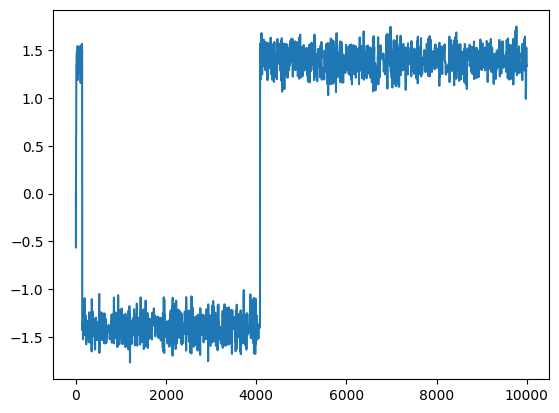

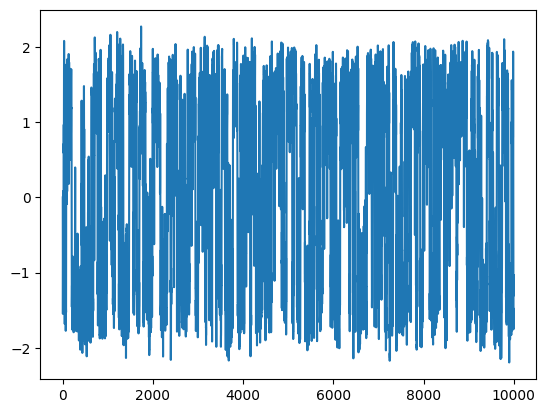

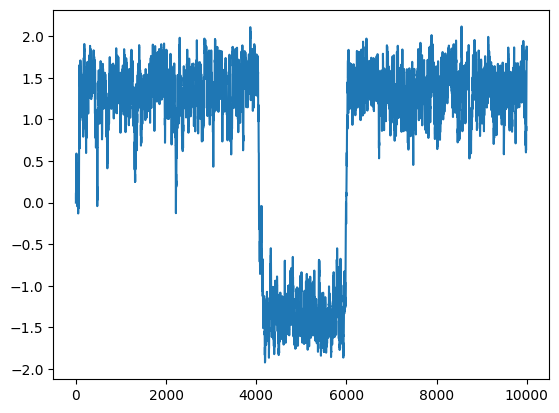

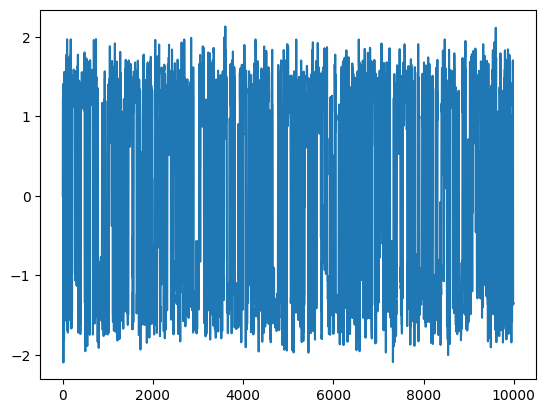

In [3]:
for chain in cadenas:
    plt.figure()
    t = np.arange(len(chain))
    plt.plot(t, chain)
    plt.show()

### d) Histogramas normalizados y comparación con $P^*(x)$

El histograma se normaliza como densidad para compararlo con la PDF teórica de Boltzmann.

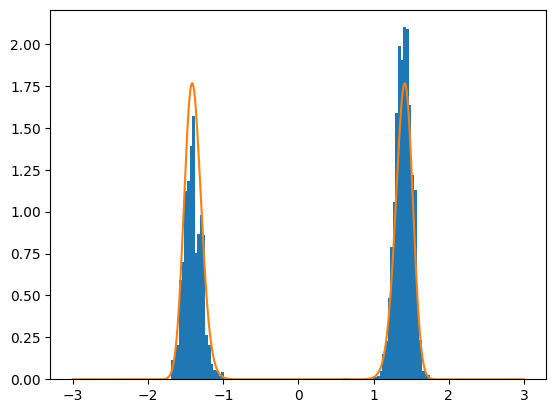

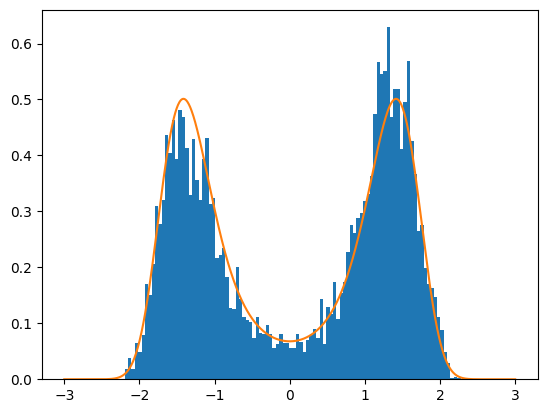

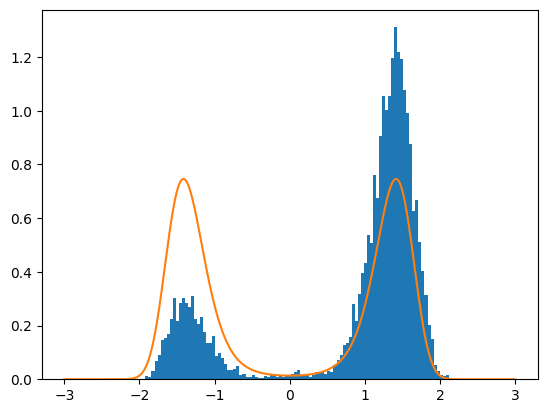

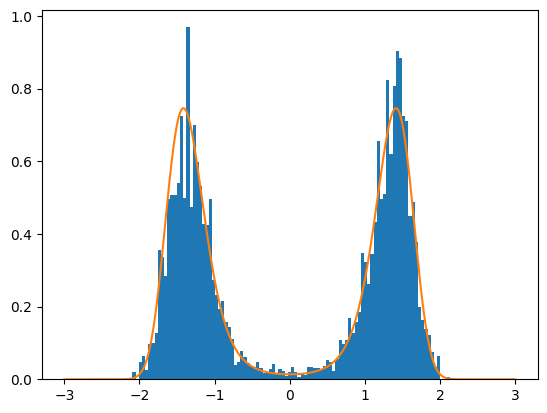

In [4]:
def boltzmann(T, xmin=-3.0, xmax=3.0, n=1000):
    x = np.linspace(xmin, xmax, n)
    distribution = np.exp(-V(x) / T)
    return x, distribution / np.trapezoid(distribution, x)

i=0
for nombre, T, sigma in casos:
    plt.figure()

    plt.hist(cadenas[i], bins=100, density=True)

    x, p = boltzmann(T)
    plt.plot(x, p)

    plt.show()
    i+=1

Los histogramas muestran máximos cerca de $x=\pm\sqrt2$. En el caso de baja temperatura la distribución queda muy concentrada en los pozos; en el caso de alta temperatura se ensancha y aparece más probabilidad cerca de la barrera. Para $T$ fija, el caso con $\sigma$ pequeño no alcanza a muestrear bien ambos pozos en la misma proporción, porque la cadena se mueve con pasos muy cortos. Con $\sigma$ grande la comparación mejora porque los saltos permiten cruzar entre pozos con más facilidad, aunque se rechacen más propuestas.